Just for sanity check of the integrity of data provided by `EquityCalculator.exe`

In [10]:
# Read the equity matrix from the binary file and reshape it into a 169x169 matrix
import numpy as np
file_path: str = r".\equity_169x169_matrix.bin"
equity_matrix: np.ndarray = np.fromfile(file_path, dtype=np.float32)
equity_matrix = equity_matrix.reshape((169, 169))
np.set_printoptions(precision=6, suppress=True, linewidth=150)

sanity_check_matrix = equity_matrix[:10, :10]

print("=== Sanity Check: Top-left 10x10 Equity Matrix ===")
print(sanity_check_matrix)

=== Sanity Check: Top-left 10x10 Equity Matrix ===
[[0.5      0.878437 0.874658 0.870379 0.866841 0.884375 0.8804   0.880609 0.882146 0.86728 ]
 [0.121563 0.5      0.712543 0.710494 0.707258 0.711702 0.709807 0.706826 0.709057 0.697775]
 [0.125342 0.287457 0.5      0.708042 0.705328 0.706577 0.70422  0.705179 0.70446  0.693616]
 [0.129621 0.289506 0.291958 0.5      0.698921 0.700507 0.697959 0.696349 0.69905  0.684445]
 [0.133159 0.292742 0.294672 0.301079 0.5      0.691252 0.68927  0.686304 0.686872 0.676118]
 [0.115625 0.288298 0.293423 0.299493 0.308748 0.5      0.66671  0.665029 0.664398 0.65088 ]
 [0.1196   0.290193 0.29578  0.302041 0.31073  0.33329  0.5      0.644268 0.644369 0.629982]
 [0.119391 0.293174 0.294821 0.303651 0.313696 0.334971 0.355732 0.5      0.614908 0.601955]
 [0.117854 0.290943 0.29554  0.30095  0.313128 0.335602 0.355631 0.385092 0.5      0.566985]
 [0.13272  0.302225 0.306384 0.315555 0.323882 0.34912  0.370018 0.398045 0.433015 0.5     ]]


In [11]:
# specific hand equity checks
rank: dict[str, int] = {'A':0, 'K':1, 'Q':2, 'J':3, 'T':4, '9':5, '8':6, '7':7, '6':8, '5':9, '4':10, '3':11, '2':12}

hero_hand: str = "AQs"
villain_hand: str = "AXs"

def hand_to_index(hand: str) -> int:
    rank1, rank2 = hand[0], hand[1]
    idx1, idx2 = rank[rank1], rank[rank2]
    if idx1 == idx2:
        return idx1 * 13 + idx2
    elif hand[2] == 's':
        return min(idx1, idx2) * 13 + max(idx1, idx2)
    else:
        return max(idx1, idx2) * 13 + min(idx1, idx2)
hero_idx: int = hand_to_index(hero_hand)

for villain_ace_high in ['K', 'Q', 'J', 'T', '9', '8', '7', '6']:
    villain_hand = f"A{villain_ace_high}s"
    villain_idx = hand_to_index(villain_hand)
    print(f"Equity of {hero_hand} vs {villain_hand}: {equity_matrix[hero_idx, villain_idx]:.4f}")
    
print("    --- wheels below ---")
for villain_wheel in ['5', '4', '3', '2']:
    villain_hand = f"A{villain_wheel}s"
    villain_idx = hand_to_index(villain_hand)
    print(f"Equity of {hero_hand} vs {villain_hand}: {equity_matrix[hero_idx, villain_idx]:.4f}")

Equity of AQs vs AKs: 0.2875
Equity of AQs vs AQs: 0.5000
Equity of AQs vs AJs: 0.7080
Equity of AQs vs ATs: 0.7053
Equity of AQs vs A9s: 0.7066
Equity of AQs vs A8s: 0.7042
Equity of AQs vs A7s: 0.7052
Equity of AQs vs A6s: 0.7045
    --- wheels below ---
Equity of AQs vs A5s: 0.6936
Equity of AQs vs A4s: 0.6975
Equity of AQs vs A3s: 0.7022
Equity of AQs vs A2s: 0.7059


frequency_matrix:
[[0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449]
 [0.007347 0.004898 0.002449 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265]
 [0.004898 0.007347 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449 0.002449]
 [0.007347 0.009796 0.007347 0.004898 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265]
 [0.007347 0.009796 0.007347 0.009796 0.004898 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265]
 [0.007347 0.009796 0.007347 0.009796 0.009796 0.004898 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265]
 [0.007347 0.009796 0.007347 0.009796 0.009796 0.009796 0.004898 0.003265 0.003265 0.003265 0.003265 0.003265 0.003265]
 [0.007347 0.009796 0.007347 0.009796 0.009796 0.009796 0.009796 0.004898 0.003265 0.003265 0.003265 0.003265 0.003265]
 [0.007347 0.009796 0.

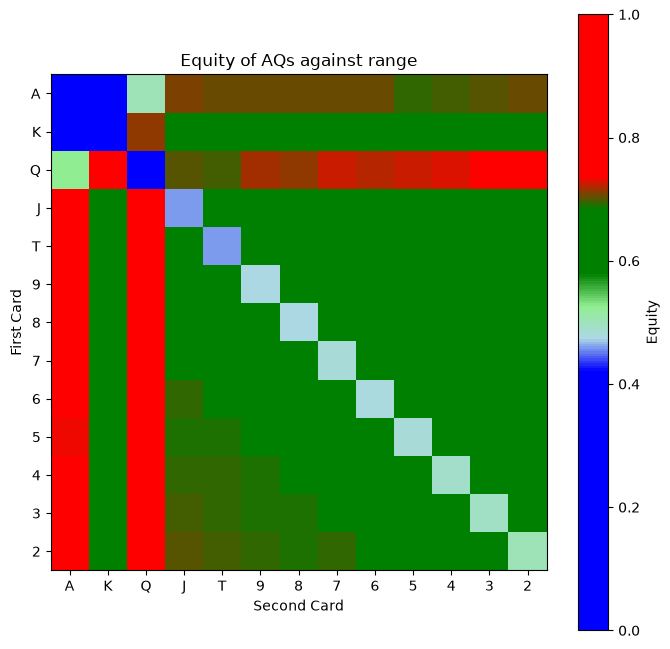

In [12]:
# Equity of a specific hand against all other hands
specific_hand: str = "AQs"
specific_idx: int = hand_to_index(specific_hand)

specific_equity_matrix: np.ndarray = equity_matrix[specific_idx, :].reshape((13, 13))
"""
FREQUENCY: list[int] = [ 6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12,  6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12,  6,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12,  6,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12,  6,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12,  6,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12,  6,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12,  6,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12,  6,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12,  6,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12,  6,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,  6, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 6]
FREQUENCY_MATRIX: np.ndarray = np.array(FREQUENCY, dtype=np.float64)
def get_frequency_matrix(hand_idx: int)->np.ndarray:
    actual_frequency: np.ndarray = FREQUENCY_MATRIX.copy().reshape(13, 13)
    row: int = hand_idx//13
    col: int = hand_idx%13
    if (row==col): # pocket pairs, also it feels so good to unlock modulus
        actual_frequency[row, col] = 4.0 # pocket pair requires further operations to be tuned down to 1
        actual_frequency[row, :] /= 2.0; # blocks half of the combos in the same row
        actual_frequency[:, col] /= 2.0; # blocks half of the combos in the same column
        return actual_frequency.flatten()
    else:
        suited_row, suited_col = (row, col) if row < col else (col, row)
        offsuit_row, offsuit_col = (row, col) if row > col else (col, row)
        actual_frequency[row, col] = 256.0 # suited counterpart requires further operations to be tuned down to 2/3
        actual_frequency[col, row] = 256.0 # offsuit counterpart requires further operations to be tuned down to 6/7
        actual_frequency[row, row], actual_frequency[col, col] = 256.0, 256.0 # involved pocket paris requires further actions to be tuned down to 3
        actual_frequency[row, :] /= 4.0;
        actual_frequency[row, :] *= 3.0;
        actual_frequency[:, col] /= 4.0;
        actual_frequency[:, col] *= 3.0; # blocks 1/4 of the combos in the larger rank
        actual_frequency[col, :] /= 4.0;
        actual_frequency[col, :] *= 3.0;
        actual_frequency[:, row] /= 4.0;
        actual_frequency[:, row] *= 3.0; # blocks 1/4 of the combos in the smaller rank
        actual_frequency[suited_row, suited_col] = 3.0 if row<col else 2.0; # suited counterpart requires further operations to be tuned down to 2/3
        actual_frequency[offsuit_row, offsuit_col] = 6.0 if row<col else 7.0; # offsuit counterpart requires further operations to be tuned down to 6/7
        actual_frequency[row, row], actual_frequency[col, col] = 3.0,3.0;
        return actual_frequency.flatten()
"""

frequency_matrix: np.ndarray = np.fromfile(r".\frequency_169x169_matrix.bin", dtype=np.float32).reshape((169, 169))
print(f"frequency_matrix:\n{frequency_matrix[specific_idx].reshape((13, 13))}")
print(f"frequency_matrix sum: {frequency_matrix[specific_idx].sum()}")
print(f"=== Rquity of {specific_hand} against range ===")
print(f"Range Equity: {(specific_equity_matrix.flatten()*frequency_matrix[specific_idx]).sum():.4f}")

print(f"=== Breakdown of Equity of {specific_hand} against all other hands ===")
print(specific_equity_matrix)
    
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# heatmap of the 13x13 equity matrix. Red for 0.0 equity, and Green for 1.0 equity
plt.figure(figsize=(8, 8))
colors = ['Blue']*9 + ['lightBlue'] + ['lightGreen'] +  ['Green']*3 + ['red']*6
custom_gradient = LinearSegmentedColormap.from_list('my_gradient', colors)
plt.imshow(specific_equity_matrix, cmap=custom_gradient, vmin=0, vmax=1)
plt.colorbar(label='Equity')
plt.xticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.yticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.xlabel('Second Card')
plt.ylabel('First Card')
plt.title(f'Equity of {specific_hand} against range')
plt.show()

**Blue**: Being Dominated (Equity < 45%)

**White**: Coin Flip (45% < Equity < 55%)

**Green**: Slight Advantage (55% < Equity < 70%)

**Red**: Dominating (70% < Equity)